In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from src.load_data_BCICIV import load_all_subjects
from src.train_EEGNet import train_model_cv
import torch
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)


# DATA LOAD

In [2]:
data_path = '../datasets/BCICIV_2a_gdf'

data_22 = load_all_subjects(data_path, channels_to_use='all')
data_22_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)], channels_to_use='all')
data_11 = load_all_subjects(data_path)
data_11_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)])

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A01T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A02T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A08T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A09T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-l

In [3]:
subjects = data_22['subject_ids'] 

X_22 = data_22['X'] 
y_22 = data_22['y'] 

X_22_multiband = data_22_multiband['X'] 
y_22_multiband = data_22_multiband['y'] 

X_11 = data_11['X'] 
y_11 = data_11['y'] 

X_11_multiband = data_11_multiband['X'] 
y_11_multiband = data_11_multiband['y'] 

In [4]:
models = {
    'model': [],
    'accuracies': [],
    'name': []
}

# Tests with 22 channels

## 22 channels (raw + normalization)

In [5]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=[], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_22')

Early stopping.
Fold 1: Train Acc = 0.8679409209383145 | Test Acc = 0.7552


Early stopping.
Fold 2: Train Acc = 0.6321739130434783 | Test Acc = 0.5278


Early stopping.
Fold 3: Train Acc = 0.811304347826087 | Test Acc = 0.7361


Early stopping.
Fold 4: Train Acc = 0.7098175499565595 | Test Acc = 0.6923


Early stopping.
Fold 5: Train Acc = 0.7295652173913043 | Test Acc = 0.6736


Early stopping.
Fold 6: Train Acc = 0.7539130434782608 | Test Acc = 0.6597


Early stopping.
Fold 7: Train Acc = 0.8095652173913044 | Test Acc = 0.6944


Early stopping.
Fold 8: Train Acc = 0.8556521739130435 | Test Acc = 0.7986


Early stopping.
Fold 9: Train Acc = 0.7573913043478261 | Test Acc = 0.5764
Mean Subject Accuracy: 0.6794
Standard Deviation: 0.0800


## 22 channels + laplacian filter on C3 and C4

In [6]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22')

Early stopping.
Fold 1: Train Acc = 0.7593397046046916 | Test Acc = 0.8322


Early stopping.
Fold 2: Train Acc = 0.5408695652173913 | Test Acc = 0.5208


Early stopping.
Fold 3: Train Acc = 0.7660869565217391 | Test Acc = 0.7222


Early stopping.
Fold 4: Train Acc = 0.8496959165942659 | Test Acc = 0.7552


Early stopping.
Fold 5: Train Acc = 0.7573913043478261 | Test Acc = 0.6736


Early stopping.
Fold 6: Train Acc = 0.7356521739130435 | Test Acc = 0.6389


Early stopping.
Fold 7: Train Acc = 0.768695652173913 | Test Acc = 0.6806


Early stopping.
Fold 8: Train Acc = 0.788695652173913 | Test Acc = 0.7569


Early stopping.
Fold 9: Train Acc = 0.5965217391304348 | Test Acc = 0.5556
Mean Subject Accuracy: 0.6818
Standard Deviation: 0.0937


## 22 channels - only mu band

In [7]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'mu_band'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_22')

Early stopping.
Fold 1: Train Acc = 0.7019982623805386 | Test Acc = 0.7133


Early stopping.
Fold 2: Train Acc = 0.6052173913043478 | Test Acc = 0.5000


Early stopping.
Fold 3: Train Acc = 0.7895652173913044 | Test Acc = 0.7292


Early stopping.
Fold 4: Train Acc = 0.6681146828844483 | Test Acc = 0.7063


Early stopping.
Fold 5: Train Acc = 0.7495652173913043 | Test Acc = 0.6319


Early stopping.
Fold 6: Train Acc = 0.7852173913043479 | Test Acc = 0.6042


Early stopping.
Fold 7: Train Acc = 0.7486956521739131 | Test Acc = 0.5972


Early stopping.
Fold 8: Train Acc = 0.7921739130434783 | Test Acc = 0.7431


Early stopping.
Fold 9: Train Acc = 0.7182608695652174 | Test Acc = 0.5556
Mean Subject Accuracy: 0.6423
Standard Deviation: 0.0804


## 22 channels - mu + beta band

In [8]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'multiband'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_22')

Early stopping.
Fold 1: Train Acc = 0.7228496959165943 | Test Acc = 0.7552


Early stopping.
Fold 2: Train Acc = 0.5478260869565217 | Test Acc = 0.5278


Early stopping.
Fold 3: Train Acc = 0.6730434782608695 | Test Acc = 0.6736


Early stopping.
Fold 4: Train Acc = 0.8523023457862728 | Test Acc = 0.7483


Early stopping.
Fold 5: Train Acc = 0.8208695652173913 | Test Acc = 0.6736


Early stopping.
Fold 6: Train Acc = 0.7730434782608696 | Test Acc = 0.6319


Early stopping.
Fold 7: Train Acc = 0.7208695652173913 | Test Acc = 0.6806


Early stopping.
Fold 8: Train Acc = 0.7556521739130435 | Test Acc = 0.7500


Early stopping.
Fold 9: Train Acc = 0.8043478260869565 | Test Acc = 0.5347
Mean Subject Accuracy: 0.6640
Standard Deviation: 0.0814


# Tests with 11 channels

## 11 channels (raw + normalization)

In [9]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=[], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_11')

Early stopping.
Fold 1: Train Acc = 0.8340573414422241 | Test Acc = 0.8182


Early stopping.
Fold 2: Train Acc = 0.7547826086956522 | Test Acc = 0.5208


Early stopping.
Fold 3: Train Acc = 0.8408695652173913 | Test Acc = 0.7153


Early stopping.
Fold 4: Train Acc = 0.7176368375325803 | Test Acc = 0.6783


Early stopping.
Fold 5: Train Acc = 0.8217391304347826 | Test Acc = 0.6667


Early stopping.
Fold 6: Train Acc = 0.6008695652173913 | Test Acc = 0.6319


Early stopping.
Fold 7: Train Acc = 0.78 | Test Acc = 0.6736


Early stopping.
Fold 8: Train Acc = 0.8547826086956521 | Test Acc = 0.7847


Early stopping.
Fold 9: Train Acc = 0.5252173913043479 | Test Acc = 0.5694
Mean Subject Accuracy: 0.6732
Standard Deviation: 0.0888


## 11 channels + laplacian filter on C3 and C4

In [10]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_11')

Early stopping.
Fold 1: Train Acc = 0.7975673327541268 | Test Acc = 0.7413


Early stopping.
Fold 2: Train Acc = 0.7347826086956522 | Test Acc = 0.6042


Early stopping.
Fold 3: Train Acc = 0.7756521739130435 | Test Acc = 0.8403


Early stopping.
Fold 4: Train Acc = 0.6516072980017377 | Test Acc = 0.6573


Early stopping.
Fold 5: Train Acc = 0.7295652173913043 | Test Acc = 0.7569


Early stopping.
Fold 6: Train Acc = 0.5573913043478261 | Test Acc = 0.5972


Early stopping.
Fold 7: Train Acc = 0.74 | Test Acc = 0.8125


Early stopping.
Fold 8: Train Acc = 0.7617391304347826 | Test Acc = 0.7153


Early stopping.
Fold 9: Train Acc = 0.6217391304347826 | Test Acc = 0.5764
Mean Subject Accuracy: 0.7002
Standard Deviation: 0.0909


## 11 channels - only mu band

In [11]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'mu_band'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_11')

Early stopping.
Fold 1: Train Acc = 0.7002606429192006 | Test Acc = 0.6713


Early stopping.
Fold 2: Train Acc = 0.6591304347826087 | Test Acc = 0.5417


Early stopping.
Fold 3: Train Acc = 0.6930434782608695 | Test Acc = 0.7986


Early stopping.
Fold 4: Train Acc = 0.5977410947002606 | Test Acc = 0.6713


Early stopping.
Fold 5: Train Acc = 0.7034782608695652 | Test Acc = 0.6736


Early stopping.
Fold 6: Train Acc = 0.5165217391304348 | Test Acc = 0.6111


Early stopping.
Fold 7: Train Acc = 0.6469565217391304 | Test Acc = 0.6944


Early stopping.
Fold 8: Train Acc = 0.788695652173913 | Test Acc = 0.6944


Early stopping.
Fold 9: Train Acc = 0.7356521739130435 | Test Acc = 0.5417
Mean Subject Accuracy: 0.6554
Standard Deviation: 0.0762


## 11 channels - mu + beta band

In [12]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'multiband'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_11')

Early stopping.
Fold 1: Train Acc = 0.73501303214596 | Test Acc = 0.7203


Early stopping.
Fold 2: Train Acc = 0.7356521739130435 | Test Acc = 0.5694


Early stopping.
Fold 3: Train Acc = 0.6782608695652174 | Test Acc = 0.8125


Early stopping.
Fold 4: Train Acc = 0.6481320590790617 | Test Acc = 0.6224


Early stopping.
Fold 5: Train Acc = 0.8295652173913044 | Test Acc = 0.7639


Early stopping.
Fold 6: Train Acc = 0.808695652173913 | Test Acc = 0.5972


Early stopping.
Fold 7: Train Acc = 0.7904347826086957 | Test Acc = 0.7986


Early stopping.
Fold 8: Train Acc = 0.7252173913043478 | Test Acc = 0.7222


Early stopping.
Fold 9: Train Acc = 0.7565217391304347 | Test Acc = 0.6042
Mean Subject Accuracy: 0.6901
Standard Deviation: 0.0877


# Visualization

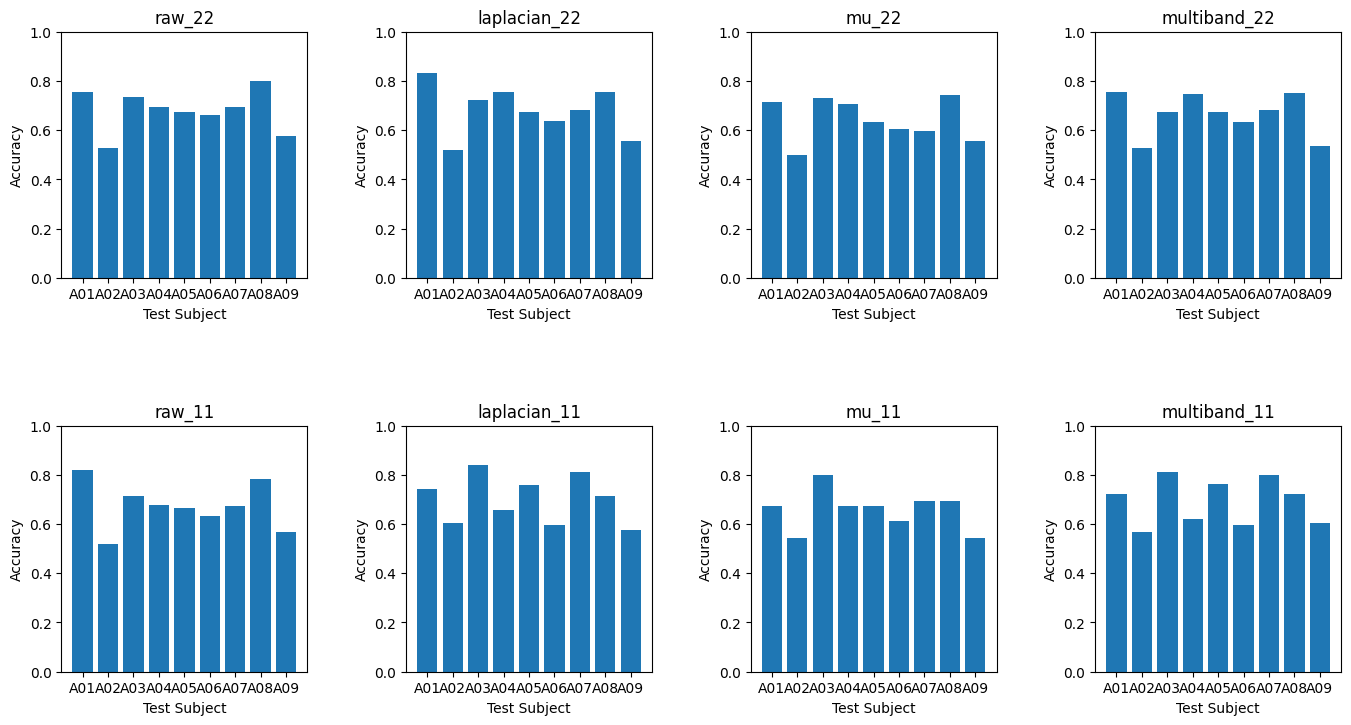

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (name, accuracies) in enumerate(zip(models['name'], models['accuracies'])):
    ax = axes[i // 4, i % 4]
    ax.bar(np.unique(subjects), accuracies)
    ax.set_title(name)
    ax.set_xlabel('Test Subject')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.6)

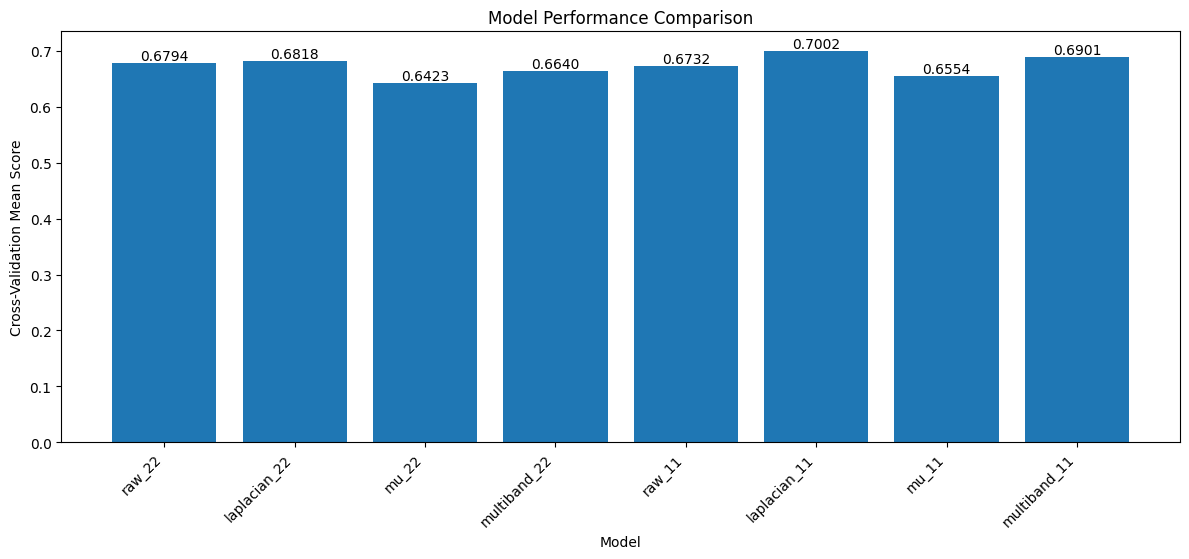

In [17]:
accs = [] 

for acc in models['accuracies']:
    accs.append(np.mean(acc))

plt.figure(figsize=(12, 6))
bars = plt.bar(models['name'], accs)
plt.xlabel('Model')
plt.ylabel('Cross-Validation Mean Score')
plt.title('Model Performance Comparison')
plt.bar_label(bars, fmt="%.4f")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95],)